In [15]:
##### Figure 2: coverage of training data

from pathlib import Path
import textwrap
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from step_thin_sample import ThinConfig, prepare_thinned_dataset

In [16]:
##### Load data

cd = Path.cwd().parent
FIG_DIR = cd / "Figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

country_info = pd.read_csv(cd / "Data" / "country_names.csv", encoding="cp1252")
country_lookup = country_info[["ISO3", "UN_region", "income_group"]]

# Set file path to figure repo
FIG_DIR = Path(f"{cd}/Figures/")
FIG_DIR.mkdir(parents=True, exist_ok=True)

In [17]:
### Prep data

# Thin data the same way as for the RF and attach region / income group

models = {}
for name in ["capital", "labor"]:
    tc = ThinConfig(name=name, raw_dataset=f"training_dataset_{name}_RF.csv")
    df = prepare_thinned_dataset(tc, f"{cd}/Data/")
    df["ISO3"] = df["PROJ_ID"].str[:3]
    models[name] = df.merge(country_lookup, on="ISO3", how="left")

# Calculate counts and shares 
regions = sorted(country_info["UN_region"].dropna().unique())
income_order = ["High income", "Upper middle income", "Lower middle income", "Low income"]
income_labels = ["High", "Upper", "Lower", "Low"]

def summarize(df, col, categories):
    counts = df[col].value_counts().reindex(categories, fill_value=0)
    return counts.to_numpy(), counts.to_numpy() / len(df) * 100


── capital ──────────────────────────────
country_ID  n_before  n_after  n_dropped  thinned
       BRA      3684      852       2832     True
       USA      2630     1053       1577     True
       CAN      1380      300       1080     True
       ARG       396      259        137     True
       TUR        80       77          3     True
       CHN        31       31          0    False
       DEU        13       13          0    False
       EGY        26       26          0    False
       ESP        17       17          0    False
       FRA        22       22          0    False
       BEL         2        2          0    False
       GRC         4        4          0    False
       HRV         2        2          0    False
       ITA        20       20          0    False
       MEX        24       24          0    False
       PRT         3        3          0    False
       ROU         8        8          0    False
       TZA        24       24          0    False
       

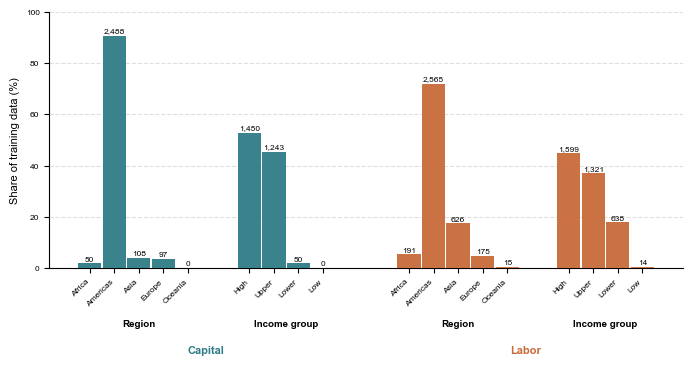

In [18]:
##### Plot figure 

# set style 
COLORS = {"capital": "#2F7C87", "labor": "#C96A3B"}

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Arial"],
    "font.size": 7,
    "axes.labelsize": 8,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
})

bar_width, within_model_gap, model_gap = 0.95, 1.5, 2.5
region_tick_labels = [textwrap.fill(str(r), width=12) for r in regions]

# plot

fig, ax = plt.subplots(figsize=(7.2, 4.2))

xticks, xticklabels = [], []
start = 0
for name, df in models.items():
    color = COLORS[name]

    region_x = start + np.arange(len(regions))
    income_x = region_x[-1] + 1 + within_model_gap + np.arange(len(income_order))
    start = income_x[-1] + 1 + model_gap

    groups = [
        (region_x, "Region", summarize(df, "UN_region", regions), region_tick_labels),
        (income_x, "Income group", summarize(df, "income_group", income_order), income_labels),
    ]

    for x, group_name, (counts, pct), tick_labels in groups:
        ax.bar(x, pct, width=bar_width, color=color, alpha=0.95, zorder=3)
        for xi, p, c in zip(x, pct, counts):
            ax.text(xi, p + 0.5, f"{int(c):,}", ha="center", va="bottom", fontsize=6)
        ax.text(x.mean(), -0.20, group_name, transform=ax.get_xaxis_transform(),
                ha="center", va="top", fontsize=7, fontweight="bold")
        xticks.extend(x)
        xticklabels.extend(tick_labels)

    ax.text(np.mean([region_x[0], income_x[-1]]), -0.3, name.capitalize(),
            transform=ax.get_xaxis_transform(), ha="center", va="top",
            fontsize=8, fontweight="bold", color=color)

ax.set_xticks(xticks)
ax.set_xticklabels(xticklabels, rotation=45, ha="right", fontsize=6)
ax.set_ylabel("Share of training data (%)")
ax.set_ylim(0, 100)
ax.spines[["top", "right"]].set_visible(False)
ax.grid(axis="y", linestyle="--", alpha=0.4, zorder=0)
ax.set_axisbelow(True)

plt.subplots_adjust(bottom=0.34, left=0.10, right=0.98, top=0.95)

plt.savefig(FIG_DIR / "FIigure_7_training_dataset.tiff", dpi=300, format="tiff")
plt.show()